# 02. Preprocessing Pipeline

- Train/Val/Test split (stratified)
- 이미지 전처리 (224x224, MobileNetV2 정규화)
- 데이터 증강 정의
- tf.data 파이프라인 구축

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import os

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = '/Users/parkyoungbin/Desktop/ml2/model/data'

TensorFlow version: 2.21.0
GPU available: False


In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'dataset_final.csv'))
labels_sorted = sorted(df['label'].unique())
label2idx = {l: i for i, l in enumerate(labels_sorted)}
idx2label = {i: l for l, i in label2idx.items()}
NUM_CLASSES = len(labels_sorted)

print(f'Classes ({NUM_CLASSES}): {labels_sorted}')
print(f'label2idx: {label2idx}')

df['label_idx'] = df['label'].map(label2idx)

Classes (9): ['Boots', 'Dress', 'Hoodie', 'Jacket', 'Jeans', 'Pants', 'Shirt', 'Sneakers', 'T-shirt']
label2idx: {'Boots': 0, 'Dress': 1, 'Hoodie': 2, 'Jacket': 3, 'Jeans': 4, 'Pants': 5, 'Shirt': 6, 'Sneakers': 7, 'T-shirt': 8}


## 1. Stratified Train/Val/Test Split (70/15/15)

In [3]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'Train: {len(train_df)}')
print(f'Val:   {len(val_df)}')
print(f'Test:  {len(test_df)}')
print(f'\nTrain label distribution:')
print(train_df['label'].value_counts().to_string())

# split 저장
train_df.to_csv(os.path.join(DATA_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(DATA_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(DATA_DIR, 'test.csv'), index=False)
print('\nSplit CSV 저장 완료')

Train: 14936
Val:   3201
Test:  3201

Train label distribution:
label
T-shirt     4986
Sneakers    3631
Shirt       1922
Boots       1256
Pants       1149
Dress        682
Jacket       468
Hoodie       423
Jeans        419



Split CSV 저장 완료


## 2. Class Weights (불균형 대응)

In [4]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_df['label_idx'].values)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}

print('Class weights:')
for i, label in enumerate(labels_sorted):
    print(f'  {label}: {class_weights[i]:.3f}')

# 저장
import json
with open(os.path.join(DATA_DIR, 'class_weights.json'), 'w') as f:
    json.dump({str(k): v for k, v in class_weights.items()}, f, indent=2)
print('\nclass_weights.json 저장 완료')

Class weights:
  Boots: 1.321
  Dress: 2.433
  Hoodie: 3.923
  Jacket: 3.546
  Jeans: 3.961
  Pants: 1.444
  Shirt: 0.863
  Sneakers: 0.457
  T-shirt: 0.333

class_weights.json 저장 완료


## 3. tf.data Pipeline 구축

In [5]:
def load_and_preprocess(image_path, label):
    """이미지 로드 + MobileNetV2 전처리"""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def augment(image, label):
    """학습용 데이터 증강"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    # 약간의 회전 효과 (crop + resize)
    image = tf.image.random_crop(
        tf.image.resize(image, [IMG_SIZE + 20, IMG_SIZE + 20]),
        [IMG_SIZE, IMG_SIZE, 3]
    )
    return image, label

def make_dataset(dataframe, training=False):
    paths = dataframe['image_path'].values
    labels = tf.one_hot(dataframe['label_idx'].values, NUM_CLASSES)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2048)
    
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

print('Pipeline 함수 정의 완료')

Pipeline 함수 정의 완료


In [6]:
# 파이프라인 테스트
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

for images, labels in train_ds.take(1):
    print(f'Batch shape: {images.shape}')
    print(f'Labels shape: {labels.shape}')
    print(f'Image range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]')
    print('Pipeline 테스트 OK')

Batch shape: (32, 224, 224, 3)
Labels shape: (32, 9)
Image range: [-1.37, 1.21]
Pipeline 테스트 OK


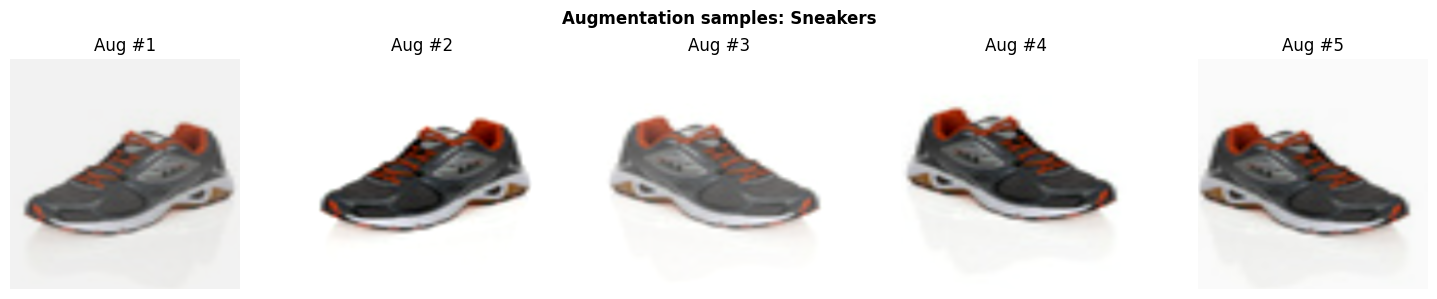

전처리 파이프라인 구축 완료


In [7]:
# 증강 샘플 시각화
import matplotlib.pyplot as plt

sample_path = train_df.iloc[0]['image_path']
sample_label = tf.one_hot(train_df.iloc[0]['label_idx'], NUM_CLASSES)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Augmentation samples: {train_df.iloc[0]["label"]}', fontweight='bold')

for i in range(5):
    img, _ = load_and_preprocess(sample_path, sample_label)
    img_aug, _ = augment(img, sample_label)
    # MobileNetV2 전처리 역변환 (시각화용)
    display_img = (img_aug.numpy() + 1.0) / 2.0
    display_img = np.clip(display_img, 0, 1)
    axes[i].imshow(display_img)
    axes[i].axis('off')
    axes[i].set_title(f'Aug #{i+1}')

plt.tight_layout()
plt.show()
print('전처리 파이프라인 구축 완료')